In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\performance_on_simulated_data'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [6]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import Simulation3ODE
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.utils import proportions_nuc_cyto

In [7]:
config_simulation = {'parameters':{ 'n_obs':800,
    'n_vars':300,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':25,
    'noise_model':"normal",
    'noise_level':2,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.4, 0.3, -0.3, 0.4, -0.2, -0.1],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[np.log(5), np.log(0.46), np.log(0.4), np.log(0.38)]} }


In [8]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':800,
#     'n_vars':300,
#     'alpha':5,
#     'beta':0.02,
#     'nu' :0.33,
#     'gamma':0.32,
#     'alpha_':0,
#     't_max':20,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':False,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     }


config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 15,
     'n_pcs': 0,
     'min_dist': 1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
                   'velovi_model_params':{'n_hidden':256,
                                    'n_latent':10,
                                    'n_layers':1,
                                    },
                    'velovi_train_params': {'epochs':600,
                                            'lr':0.01,
                                            'weight_decay':0.01,
                                            'early_stop':True,
                                            'batch_size':256}}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



# Simulation 

In [9]:
simulator = Simulation3ODE(config= config_simulation) 
adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[800], n_vars_list=[300])
# adata_dict = simulator.simulation()

mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0.36   0.144 -0.072]
 [ 0.108  0.144  0.36  -0.036]
 [-0.108 -0.072 -0.036  0.36 ]]
6.049984347299238
0.5636800698309166
0.5062425799333777
0.44702934116233395


In [11]:
adata_dict.keys()

dict_keys(['adata_s_u_800obs_300genes', 'adata_n_c_800obs_300genes'])

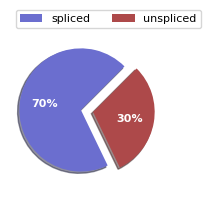

In [10]:
scv.pl.proportions(adata_dict['adata_s_u_800obs_300genes'])

<Axes: >

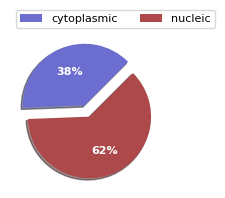

In [11]:
proportions_nuc_cyto(adata_dict['adata_n_c_800obs_300genes'])

# Preprocessing 

In [12]:
for key, adata in adata_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata = preprocessor.preprocess_data()

adata_s_u_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


# Velocity 

In [13]:
velocity_computer = Velocities(adata_dict,config_velocity)

Using device: cuda


In [14]:
adata_dict_velocity = velocity_computer.compute_velocities()

deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:22) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:25) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A2000 8GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 580/600:  97%|█████████▋| 580/600 [00:59<00:02,  9.77it/s, v_num=1, train_loss_step=1.14e+3, train_loss_epoch=1.13e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1144.403. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 450/600:  75%|███████▌  | 450/600 [00:37<00:12, 11.95it/s, v_num=1, train_loss_step=1.29e+3, train_loss_epoch=1.27e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1285.906. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Save adatas 

In [15]:
os.getcwd()

saving_path = os.path.join(os.getcwd(),'data','perf_sim_data')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

vae = adata_dict_velocity[0]

np.save(os.path.join(saving_path_vae,'perf_sim_data'), vae) 


adata_dict = adata_dict_velocity[1]

for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_800obs_300genes_deterministic
adata_s_u_800obs_300genes_stochastic
adata_s_u_800obs_300genes_dynamical
adata_s_u_800obs_300genes_velovi
adata_n_c_800obs_300genes_deterministic
adata_n_c_800obs_300genes_stochastic
adata_n_c_800obs_300genes_dynamical
adata_n_c_800obs_300genes_velovi


In [18]:
saving_path = os.path.join(os.getcwd(),'data','perf_sim_data')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

In [19]:
vae = adata_dict_velocity[0]

In [20]:
np.save(os.path.join(saving_path_vae,'800_1103'), vae) 

In [21]:
adata_dict = adata_dict_velocity[1]

In [22]:
for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_s_u_800obs_300genes_deterministic
adata_s_u_800obs_300genes_stochastic
adata_s_u_800obs_300genes_dynamical
adata_s_u_800obs_300genes_velovi
adata_n_c_800obs_300genes_deterministic
adata_n_c_800obs_300genes_stochastic
adata_n_c_800obs_300genes_dynamical
adata_n_c_800obs_300genes_velovi
